# Thesis: compare the two lyric emotion models

This notebook compares **our frozen MiniLM embeddings + GoEmotions logistic classifier** with
**Hartmann's `j-hartmann/emotion-english-distilroberta-base`**, the checkpoint named in the original
Twitter–Music paper. Both predict the same seven categories: anger, disgust, fear, joy, neutral,
sadness and surprise. Logistic regression here is a **categorical classifier**, not continuous VAD regression.

**Use only `Thesis_DistilRoBERTa_inputs.zip` with this notebook.** It contains the cleaned retained lyrics,
the original predictions, song mapping and folds. No raw tweet download, embedding download or model
training on GoEmotions is required. Colab downloads the public DistilRoBERTa model once.

Select **Runtime → Change runtime type → T4 GPU**, then run the cells in order. A CPU can run it,
but scoring all 30,392 distinct lyric strings will be slower. Put the intact companion ZIP at the top
level of `MyDrive`, or use the direct-upload option. Drive storage preserves checkpoints across sessions;
direct upload uses temporary storage. The final cell creates and downloads a results ZIP.

The comparison keeps **4,256 participants (754 depression-labelled, 3,502 controls), 6,345,978 eligible
tweets and 47,204 participant–song records**. Tweet category scores, VAD values, cohort selection and
five participant folds stay fixed. We change the lyric category scoring pipeline and repeat:

1. Agreement between the two lyric models, at distinct-lyric and participant levels.
2. Group differences and tweet–lyric relationships, including differences between group correlations.
3. Depression/control classification with lyric categories, combined categories, and VAD plus categories.
4. Paired changes in AUROC and the added contribution of lyrics beyond the unchanged tweet baseline.

This is an **exploratory sensitivity analysis after the primary results**, rather than an exact replication
of the paper or a new independent validation. Each model scores the full cleaned lyric using its own
tokenizer/context limit, with non-overlapping chunks and token-weighted averaging; chunk boundaries
therefore differ. Both participant profiles average equally over the same retained songs.

Agreement measures consistency between models, **not emotion accuracy**: no human-rated target emotion
labels are available. Hartmann was trained on several datasets including GoEmotions, so we do not treat
our GoEmotions test split as a clean held-out benchmark for that checkpoint. Disclosure-derived depression
labels and shared songs do not establish clinical diagnoses, listening behaviour or causal effects.


## 1. Install packages
Start with a fresh Colab runtime. The numerical/classifier versions match your completed primary Colab
run. PyTorch supplied by Colab is retained. If Colab requests a restart, restart once and continue at Step 2.


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'numpy==2.1.3', 'pandas==2.2.3', 'scipy==1.16.3', 'scikit-learn==1.6.1',
    'transformers==4.57.6', 'huggingface-hub==0.36.0', 'tokenizers==0.22.2',
    'matplotlib>=3.8,<4', 'statsmodels>=0.14,<1', 'tqdm'])


0

## 2. Choose storage and find the input ZIP


In [ ]:
from google.colab import drive, files
from pathlib import Path

STORAGE_MODE = 'auto'  # 'auto', 'drive', or 'upload'
assert STORAGE_MODE in ['auto', 'drive', 'upload']
DRIVE_AVAILABLE = False

if STORAGE_MODE != 'upload':
    try:
        if not Path('/content/drive/MyDrive').is_dir():
            drive.mount('/content/drive', force_remount=True, timeout_ms=180000)
        DRIVE_AVAILABLE = Path('/content/drive/MyDrive').is_dir()
        if not DRIVE_AVAILABLE:
            raise ValueError('Drive did not expose MyDrive.')
    except Exception as exc:
        if STORAGE_MODE == 'drive':
            raise RuntimeError("Drive failed. Set STORAGE_MODE='upload' and rerun this cell.") from exc
        print('Drive unavailable:', type(exc).__name__, str(exc))
        print('Continuing with direct upload and temporary storage.')

BASE = Path('/content/drive/MyDrive') if DRIVE_AVAILABLE else Path('/content')
INPUT_ZIP = BASE/'Thesis_DistilRoBERTa_inputs.zip'
PROJECT = BASE/'Thesis_DistilRoBERTa_Comparison'

if not INPUT_ZIP.is_file():
    print('Select Thesis_DistilRoBERTa_inputs.zip from your computer.')
    uploaded = files.upload(target_dir='/content')
    candidates = [Path(name) for name in uploaded if str(name).lower().endswith('.zip')]
    if len(candidates) != 1:
        raise ValueError('Select exactly one companion ZIP and rerun this cell.')
    INPUT_ZIP = candidates[0]
    if not INPUT_ZIP.is_absolute():
        INPUT_ZIP = Path('/content')/INPUT_ZIP
    del uploaded
    assert INPUT_ZIP.is_file(), 'Uploaded ZIP could not be found.'

BOOTSTRAPS = 2000
INCLUDE_RANDOM_FOREST = True
BATCH_SIZE = 24
SEED = 42
CODE_VERSION = 'thesis-distilroberta-comparison-v1'
MODEL_ID = 'j-hartmann/emotion-english-distilroberta-base'
MODEL_REVISION = '0e1cd914e3d46199ed785853e12b57304e04178b'
INPUT = Path('/content/thesis_distilroberta_inputs/distilroberta_comparison_inputs')
CACHE = PROJECT/'cache'
RESULTS = PROJECT/'results'

for path in [INPUT.parent, PROJECT, CACHE, RESULTS, RESULTS/'analysis', RESULTS/'figures']:
    path.mkdir(parents=True, exist_ok=True)
print('New results:', RESULTS)

if not DRIVE_AVAILABLE:
    print('Temporary storage: download the final results ZIP before ending the runtime.')


Mounted at /content/drive
New results: /content/drive/MyDrive/Thesis_DistilRoBERTa_Comparison/results


## 3. Verify the input files and reconstruct the original lyric means
The companion manifest verifies every input file. The notebook checks the exact participant IDs, group
labels, song counts, folds and saved predictions. It also independently averages the old lyric scores
using the supplied song mapping and requires them to reproduce the original participant features.


In [ ]:
import hashlib, importlib.metadata, json, platform, shutil, time, warnings, zipfile
import numpy as np
import pandas as pd
import scipy, sklearn
import matplotlib.pyplot as plt
from scipy.stats import rankdata, spearmanr, mannwhitneyu
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, cohen_kappa_score
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm
from IPython.display import display, Markdown

LABELS = ['anger','disgust','fear','joy','neutral','sadness','surprise']
TCOLS = ['tweet_emotion_'+s for s in LABELS]
LCOLS = ['lyric_emotion_'+s for s in LABELS]
VADCOLS = [s+'_'+d for s in ['tweet','lyric'] for d in ['V','A','D']]
PACKAGE_VERSIONS = {p: importlib.metadata.version(p) for p in
    ['numpy','pandas','scipy','scikit-learn','matplotlib','statsmodels','torch',
     'transformers','huggingface-hub','tokenizers']}
for name, module, expected in [('numpy',np,'2.1.3'), ('pandas',pd,'2.2.3'),
                               ('scipy',scipy,'1.16.3'), ('scikit-learn',sklearn,'1.6.1')]:
    assert module.__version__ == PACKAGE_VERSIONS[name] == expected, 'Restart runtime or rerun installation: '+name
assert PACKAGE_VERSIONS['transformers'] == '4.57.6'

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(8*1024*1024), b''):
            h.update(block)
    return h.hexdigest()

def write_json(path, value):
    path = Path(path); temp = path.with_name(path.name+'.partial')
    temp.write_text(json.dumps(value, indent=2, allow_nan=False)); temp.replace(path)

def save_npz(path, **arrays):
    path = Path(path); temp = path.with_name(path.name+'.partial')
    with temp.open('wb') as f:
        np.savez_compressed(f, **arrays)
    temp.replace(path)

def save_figure(fig, name):
    fig.savefig(RESULTS/'figures'/(name+'.png'), dpi=180, bbox_inches='tight')
    fig.savefig(RESULTS/'figures'/(name+'.pdf'), bbox_inches='tight')
    plt.show(); plt.close(fig)

with zipfile.ZipFile(INPUT_ZIP) as z:
    for info in z.infolist():
        assert (INPUT.parent/info.filename).resolve().is_relative_to(INPUT.parent.resolve()), 'Unsafe ZIP member.'
    assert z.testzip() is None, 'Corrupt input ZIP.'
    z.extractall(INPUT.parent)
input_manifest = json.loads((INPUT/'INPUT_MANIFEST.json').read_text())
assert input_manifest['bundle_version'] == 'distilroberta-inputs-v1'
for name, info in tqdm(input_manifest['files'].items(), desc='Checking inputs'):
    path = INPUT/name
    assert path.stat().st_size == info['bytes'] and sha256(path) == info['sha256'], name

features = pd.read_csv(INPUT/'original/analysis/participant_features.csv', dtype={'participant_id':str})
folds = pd.read_csv(INPUT/'support/fold_assignments.csv', dtype={'participant_id':str})
old_lyrics = pd.read_csv(INPUT/'support/lyric_emotions_minilm.csv', dtype={'lyric_id':str})
songs = pd.read_csv(INPUT/'support/participant_song_map.csv', dtype={'participant_id':str,'lyric_id':str})
old_oof = pd.read_csv(INPUT/'original/analysis/classification_oof.csv', dtype={'participant_id':str})
old_summary = pd.read_csv(INPUT/'original/analysis/classification_summary.csv')
source_manifest = json.loads((INPUT/'original/model/manifest.json').read_text())
assert len(features)==4256 and features.participant_id.is_unique
assert features.disorder.value_counts().to_dict()=={'control':3502,'depression':754}
assert features.participant_id.tolist()==folds.participant_id.tolist()
assert features.disorder.tolist()==folds.disorder.tolist() and set(folds.fold)==set(range(1,6))
assert len(songs)==47204 and len(old_lyrics)==30392 and old_lyrics.lyric_id.is_unique
assert set(songs.lyric_id)==set(old_lyrics.lyric_id) and set(songs.participant_id)==set(features.participant_id)
assert not songs.duplicated(['participant_id','artist','title']).any()

expected = features.set_index('participant_id')
assert (songs.disorder==songs.participant_id.map(expected.disorder)).all()
assert np.array_equal(songs.groupby('participant_id').size().reindex(expected.index), expected.song_count)
assert old_lyrics.token_count.between(1,4000).all()
assert int(features.tweet_count.sum())==6345978 and int(features.song_count.sum())==47204
assert np.isfinite(features[TCOLS+LCOLS+VADCOLS].to_numpy()).all()

for cols in [TCOLS,LCOLS]:
    assert features[cols].ge(0).all().all() and np.allclose(features[cols].sum(axis=1),1,atol=1e-10)

rebuilt = songs[['participant_id','lyric_id']].merge(old_lyrics, on='lyric_id', validate='many_to_one').groupby('participant_id')[LCOLS].mean().loc[expected.index]
old_reproduction_error = float(np.max(np.abs(rebuilt.to_numpy()-expected[LCOLS].to_numpy())))
assert old_reproduction_error < 1e-12

features['fold'] = folds.fold.to_numpy()
y = features.disorder.eq('depression').to_numpy(dtype=int)

for (name,model), part in old_oof.groupby(['features','model']):
    assert len(part)==4256 and part.participant_id.is_unique
    part = part.set_index('participant_id').loc[features.participant_id]
    assert np.array_equal(part.y,y) and np.array_equal(part.fold,features.fold)
    assert part.probability.between(0,1).all() and np.isfinite(part.probability).all()
    assert np.array_equal(part.predicted,part.probability.gt(.5).astype(int))
    saved_auc = old_summary[(old_summary.features==name)&(old_summary.model==model)].pooled_auroc.iloc[0]
    assert abs(roc_auc_score(y,part.probability)-saved_auc)<1e-12

texts = [json.loads(line) for line in (INPUT/'support/cleaned_lyrics.jsonl').open()]
assert [r['lyric_id'] for r in texts]==old_lyrics.lyric_id.tolist()

for row in texts:
    assert row['cleaned'].strip() and hashlib.sha256(row['cleaned'].encode()).hexdigest()==row['lyric_id']

print(f'All inputs verified. Old lyric mean reproduction difference: {old_reproduction_error:.2e}')
display(features.groupby('disorder')[['tweet_count','song_count']].agg(['count','median','mean']))


Checking inputs:   0%|          | 0/12 [00:00<?, ?it/s]

All inputs verified. Old lyric mean reproduction difference: 1.67e-16


tweet_count                      song_count                  
                 count  median         mean      count median       mean
disorder                                                                
control           3502  1595.0  1427.924615       3502    3.0  11.633067
depression         754  1998.0  1784.331565        754    3.0   8.574271

## 4. Record the comparison plan
The original same-predictor analysis stays the primary analysis. The new mixed-predictor pipeline is a
sensitivity comparison. No emotion model or depression classifier is tuned using held-out participants.

Group effects use Mann–Whitney tests and Cliff's delta. BH correction is applied to the same 14 tweet/lyric
category tests **within each pipeline**. Matching correlations use separate seven-test families within each
pipeline/group. Formal between-group correlation differences use ten tests within each pipeline: the seven
categories plus the three unchanged VAD dimensions. These separate exploratory families do not provide
an overall study-wide error rate. Paired AUROC intervals are pointwise and unadjusted.


In [ ]:
assert BOOTSTRAPS==2000 and SEED==42 and BATCH_SIZE>=1

plan = {
    'code_version':CODE_VERSION, 'input_zip_sha256':sha256(INPUT_ZIP),
    'scope':'Exploratory sensitivity selected after primary results; not externally preregistered.',
    'original_model_sha256':source_manifest['model_sha256'],
    'new_model':MODEL_ID, 'new_model_revision':MODEL_REVISION,
    'cohort':'Fixed original 4256 participants, 47204 participant-song records, 30392 lyric strings.',
    'tweet_and_VAD_values':'Unchanged; original OOF baselines reused verbatim.',
    'lyric_aggregation':'Full cleaned text; non-overlapping 510-content-token RoBERTa chunks, score before token-weighted averaging; equal weight per retained song at participant level.',
    'comparison_scope':'Scoring pipelines differ in checkpoint, tokenizer, training and chunk boundaries; not a pure architecture comparison or exact paper replication.',
    'agreement':'Pearson/Spearman, mean absolute score difference, signed score shift and top-category agreement/kappa; not human-rated accuracy.',
    'group_tests':'Mann-Whitney and Cliff delta; BH14 separately within each pipeline.',
    'matching_correlations':'Spearman; BH7 per pipeline/group; participant percentile bootstrap intervals.',
    'group_correlation_differences':'Seven categories plus unchanged VAD3; depression-minus-control; basic bootstrap CIs and approximate centred-bootstrap two-sided p-values; BH10 per pipeline.',
    'classification':'Original five participant folds; LR balanced C1 with train-fold median imputation/scaling; RF300 leaf3 balanced_subsample; seed42; no tuning.',
    'feature_sets':['category_tweets','category_lyrics','category_both','VAD_and_categories','VAD_both'],
    'prediction_comparisons':'Paired pooled OOF AUROC changes; lyrics increment; VAD increment; unadjusted label-stratified bootstrap intervals.',
    'uncertainty':'Conditional participant resampling; omits full model retraining, shared-song clustering and social dependence.',
    'bootstraps':BOOTSTRAPS, 'include_random_forest':INCLUDE_RANDOM_FOREST,
    'bootstrap_seed_bases':{'score_shifts':3100,'group_effects':4100,'matching':5100,
                           'group_correlation_differences':20261020,'classification':7100,'paired_AUROC':8100},
    'packages':PACKAGE_VERSIONS,
}

plan_path = RESULTS/'analysis/comparison_plan.json'

if plan_path.exists():
    previous = json.loads(plan_path.read_text())
    assert {k:v for k,v in previous.items() if k!='recorded_utc'}==plan, 'Settings/packages changed: use a new PROJECT folder.'
else:
    write_json(plan_path, dict(plan,recorded_utc=time.strftime('%Y-%m-%dT%H:%M:%SZ',time.gmtime())))

for name in ['run_manifest.json','OUTPUT_HASHES.json','COMPARISON_SUMMARY.md']:
    (RESULTS/name).unlink(missing_ok=True)  # Completion is recorded again only after all steps finish.
CHECK_STATUS = {}

print('Plan recorded. This run must finish Step 12 before its results are considered complete.')


Plan recorded. This run must finish Step 12 before its results are considered complete.


## 5. Load the fixed model and prepare full-lyric chunks
The exact checkpoint revision is fixed. Labels are read from its configuration and reordered explicitly.
Long lyrics are split into up to 510 content tokens plus the model's two special tokens. Every content
token is scored once; nothing is silently truncated. Tokenized chunks are cached separately from results.


In [ ]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['HF_HOME'] = str(CACHE/'huggingface')

import torch, transformers
from packaging.version import Version
from transformers import AutoTokenizer, AutoModelForSequenceClassification
assert transformers.__version__==PACKAGE_VERSIONS['transformers']
assert Version(torch.__version__.split('+')[0]) >= Version('2.6'), 'Use a fresh current Colab runtime (PyTorch >=2.6 required).'
torch.manual_seed(SEED)
torch.set_float32_matmul_precision('highest')

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION, cache_dir=CACHE/'hf_models')
emotion_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION, cache_dir=CACHE/'hf_models',
    use_safetensors=False, attn_implementation='eager').to(DEVICE).eval()

model_labels = {int(k):str(v).lower() for k,v in emotion_model.config.id2label.items()}
assert sorted(model_labels)==list(range(7)) and set(model_labels.values())==set(LABELS)

LABEL_ORDER = [next(k for k,v in model_labels.items() if v==label) for label in LABELS]
MAX_LENGTH = int(tokenizer.model_max_length)
SPECIAL_TOKENS = tokenizer.num_special_tokens_to_add(pair=False)
assert MAX_LENGTH==512 and SPECIAL_TOKENS==2

CONTENT_LIMIT = MAX_LENGTH-SPECIAL_TOKENS
assert emotion_model.config.max_position_embeddings==514
scoring_definition = {'code_version':CODE_VERSION,'model':MODEL_ID,'revision':MODEL_REVISION,
    'labels':LABELS,'content_limit':CONTENT_LIMIT,'full_text':True,'overlap':0,
    'aggregation':'content-token-weighted chunk probabilities',
    'text_sha256':sha256(INPUT/'support/cleaned_lyrics.jsonl'),
    'model_packages':{p:PACKAGE_VERSIONS[p] for p in ['torch','transformers','huggingface-hub','tokenizers']},
    'precision':'float32; eager attention; TF32 disabled'}

SCORE_KEY = hashlib.sha256(json.dumps(scoring_definition,sort_keys=True).encode()).hexdigest()

token_path = CACHE/('tokens_'+SCORE_KEY+'.npz')

if not token_path.exists():
    chunk_ids=[]; owners=[]; lengths=[]; token_counts=[]
    for index,row in enumerate(tqdm(texts,desc='Tokenizing full lyrics')):
        ids = tokenizer(row['cleaned'],add_special_tokens=False,truncation=False,
                        return_attention_mask=False,verbose=False)['input_ids']
        assert len(ids)>0
        token_counts.append(len(ids))
        for start in range(0,len(ids),CONTENT_LIMIT):
            part=ids[start:start+CONTENT_LIMIT]
            chunk_ids.append(part); owners.append(index); lengths.append(len(part))
    offsets=np.r_[0,np.cumsum(lengths)].astype(np.int64)
    flat=np.concatenate([np.asarray(ids,dtype=np.int32) for ids in chunk_ids])
    save_npz(token_path, flat=flat,offsets=offsets,owners=np.array(owners,dtype=np.int64),
             lengths=np.array(lengths,dtype=np.int64),token_counts=np.array(token_counts,dtype=np.int64),
             score_key=np.array(SCORE_KEY))
    del chunk_ids, flat

with np.load(token_path,allow_pickle=False) as saved:
    assert str(saved['score_key'])==SCORE_KEY
    flat=saved['flat'].copy(); offsets=saved['offsets'].copy(); owners=saved['owners'].copy()
    lengths=saved['lengths'].copy(); token_counts=saved['token_counts'].copy()
assert len(token_counts)==len(texts) and len(owners)==len(lengths)==len(offsets)-1
assert np.array_equal(np.diff(offsets),lengths) and offsets[-1]==len(flat)
assert np.array_equal(np.unique(owners),np.arange(len(texts))) and np.all(np.diff(owners)>=0)
assert lengths.min()>0 and lengths.max()<=CONTENT_LIMIT
assert np.array_equal(np.bincount(owners,weights=lengths,minlength=len(texts)),token_counts)

print('Device:',DEVICE,'| Distinct lyrics:',len(texts),'| Chunks:',len(owners))

if DEVICE.type=='cpu':
    print('CPU')

write_json(RESULTS/'analysis/emotion_model_definition.json',dict(scoring_definition,
    score_key=SCORE_KEY,label_id_mapping=model_labels,device=str(DEVICE)))


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Tokenizing full lyrics:   0%|          | 0/30392 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Device: cuda | Distinct lyrics: 30392 | Chunks: 43705


## 6. Score the lyrics and save progress
Scores are softmax probabilities across seven categories for each chunk, then averaged within a lyric
in proportion to content-token counts. These are model scores, not validated probabilities that a person
feels each emotion. Checkpoints contain complete blocks of 256 lyrics; a partial interrupted block is
recomputed. An out-of-memory error reduces the batch size automatically.


In [ ]:
def score_chunk_indices(indices,batch_size):
    result=np.empty((len(indices),7),dtype=np.float64)
    start=0

    while start<len(indices):
        end=min(start+batch_size,len(indices))
        ids=[]
        for index in indices[start:end]:
            content=flat[offsets[index]:offsets[index+1]].tolist()
            sequence=tokenizer.build_inputs_with_special_tokens(content)
            assert len(sequence)==len(content)+SPECIAL_TOKENS and len(sequence)<=MAX_LENGTH
            ids.append({'input_ids':sequence,'attention_mask':[1]*len(sequence)})
        try:
            batch=tokenizer.pad(ids,padding=True,return_tensors='pt')
            batch={k:v.to(DEVICE) for k,v in batch.items() if k in ['input_ids','attention_mask']}
            with torch.inference_mode():
                probability=torch.softmax(emotion_model(**batch).logits.float(),dim=-1)
            result[start:end]=probability[:,LABEL_ORDER].cpu().numpy()
            start=end
            del batch,probability
        except torch.OutOfMemoryError:
            if batch_size==1:
                raise RuntimeError('GPU memory exhausted at batch size 1. Restart runtime and reconnect to the same Drive project.')
            batch_size=max(1,batch_size//2)
            if DEVICE.type=='cuda': torch.cuda.empty_cache()
            print('Reducing inference batch size to',batch_size)
    assert np.isfinite(result).all() and (result>=0).all() and np.allclose(result.sum(axis=1),1,atol=1e-6)
    return result

score_dir=CACHE/('lyric_scores_'+SCORE_KEY)
score_dir.mkdir(exist_ok=True)
BLOCK_LYRICS=256
new_scores=np.full((len(texts),7),np.nan)
new_chunk_counts=np.bincount(owners,minlength=len(texts))

for first in tqdm(range(0,len(texts),BLOCK_LYRICS),desc='Scoring/checkpointing lyrics'):
    last=min(first+BLOCK_LYRICS,len(texts))
    path=score_dir/f'lyrics_{first:06d}_{last:06d}.npz'
    if path.exists():
        with np.load(path,allow_pickle=False) as state:
            assert str(state['score_key'])==SCORE_KEY and int(state['first'])==first and int(state['last'])==last
            block_scores=state['scores'].copy()
    else:
        indices=np.flatnonzero((owners>=first)&(owners<last))
        probabilities=score_chunk_indices(indices,BATCH_SIZE)
        sums=np.zeros((last-first,7),dtype=np.float64)
        np.add.at(sums,owners[indices]-first,probabilities*lengths[indices,None])
        block_scores=sums/token_counts[first:last,None]
        assert np.isfinite(block_scores).all() and np.allclose(block_scores.sum(axis=1),1,atol=1e-6)
        save_npz(path,score_key=np.array(SCORE_KEY),first=np.array(first),last=np.array(last),scores=block_scores)
    assert block_scores.shape==(last-first,7) and np.isfinite(block_scores).all()
    assert (block_scores>=0).all() and np.allclose(block_scores.sum(axis=1),1,atol=1e-6)
    new_scores[first:last]=block_scores
assert np.isfinite(new_scores).all()

new_lyrics=pd.DataFrame(new_scores,columns=LCOLS)
new_lyrics.insert(0,'lyric_id',old_lyrics.lyric_id.to_numpy())
new_lyrics['original_minilm_token_count']=old_lyrics.token_count.to_numpy()
new_lyrics['distilroberta_content_tokens']=token_counts
new_lyrics['distilroberta_chunks']=new_chunk_counts
new_lyrics.to_csv(RESULTS/'analysis/lyric_emotions_distilroberta.csv',index=False)
old_lyrics.to_csv(RESULTS/'analysis/lyric_emotions_minilm.csv',index=False)

write_json(RESULTS/'analysis/scoring_audit.json',{
    'score_key':SCORE_KEY,'distinct_lyrics':len(texts),'chunks':len(owners),
    'content_tokens':int(token_counts.sum()),'processed_content_tokens':int(lengths.sum()),
    'lyrics_requiring_multiple_chunks':int((new_chunk_counts>1).sum()),
    'content_limit':CONTENT_LIMIT,'overlap':0,'truncated_content_tokens':0,
    'old_participant_mean_reproduction_max_difference':old_reproduction_error,
    'mean_weighting':'Content-token-weighted chunks; equal-weight retained song rows per participant.'})

CHECK_STATUS['full_lyric_scoring']=True

print('All lyrics scored and cached. Subsequent cells use participant-level data.')


Scoring/checkpointing lyrics:   0%|          | 0/119 [00:00<?, ?it/s]

You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


All lyrics scored and cached. Subsequent cells use participant-level data.


## 7. Build the alternative participant profiles
The exact same song rows contribute to both lyric profiles. A shared lyric is scored once and reused
for its song rows. No tweet feature, VAD value, label, count, participant or fold is changed.


In [ ]:
new_means=songs[['participant_id','lyric_id']].merge(new_lyrics[['lyric_id']+LCOLS],on='lyric_id',validate='many_to_one').groupby('participant_id')[LCOLS].mean().loc[features.participant_id]
alternative=features.copy()
alternative[LCOLS]=new_means.to_numpy()
unchanged=[c for c in features if c not in LCOLS]

pd.testing.assert_frame_equal(features[unchanged],alternative[unchanged])
assert np.isfinite(alternative[LCOLS].to_numpy()).all()
assert np.allclose(alternative[LCOLS].sum(axis=1),1,atol=1e-6)

features.to_csv(RESULTS/'analysis/participant_features_minilm.csv',index=False)
alternative.to_csv(RESULTS/'analysis/participant_features_distilroberta.csv',index=False)
PIPELINES={'MiniLM_GoEmotions':features,'DistilRoBERTa_lyrics':alternative}

write_json(RESULTS/'analysis/cohort_audit.json',{
    'participants':len(features),'groups':features.disorder.value_counts().to_dict(),
    'tweet_count':int(features.tweet_count.sum()),'participant_song_records':len(songs),
    'distinct_lyrics':int(songs.lyric_id.nunique()),'folds_unchanged':True,
    'tweet_scores_unchanged':True,'VAD_unchanged':True,'song_counts_unchanged':True})

CHECK_STATUS['participant_profiles']=True


## 8. Do the two models produce similar lyric profiles?
`mean_absolute_score_difference` is the average distance between predictions, **not prediction error**
against a correct emotion label. A positive mean shift means higher scores from DistilRoBERTa.
Each distinct cleaned lyric has one weight in the lyric comparison; each participant has one weight in
the participant comparison. The participant shift intervals resample paired profiles. Distinct-lyric
agreement is descriptive because lyrics and song records are not independent human-rated observations.


,level,emotion,n,pearson_r,spearman_rho,minilm_mean,distilroberta_mean,mean_signed_shift,mean_absolute_score_difference,shift_ci_low,shift_ci_high
0,distinct_lyric,anger,30392,0.540556,0.564661,0.097201,0.176735,0.079534,0.117393,NaN,NaN
1,distinct_lyric,disgust,30392,0.480854,0.543721,0.006653,0.070864,0.064211,0.064807,NaN,NaN
2,distinct_lyric,fear,30392,0.316123,0.372914,0.009873,0.183563,0.173690,0.174585,NaN,NaN
3,distinct_lyric,joy,30392,0.366493,0.316880,0.315476,0.077553,-0.237923,0.258134,NaN,NaN
4,distinct_lyric,neutral,30392,0.249896,0.267718,0.357631,0.195892,-0.161739,0.211763,NaN,NaN
5,distinct_lyric,sadness,30392,0.422793,0.391282,0.061798,0.206152,0.144354,0.163882,NaN,NaN
6,distinct_lyric,surprise,30392,0.196284,0.126725,0.151369,0.089242,-0.062127,0.120434,NaN,NaN
7,participant,anger,4256,0.572315,0.602898,0.083876,0.150985,0.067109,0.085790,0.063719,0.070480
8,participant,disgust,4256,0.539127,0.605996,0.005901,0.062484,0.056584,0.056774,0.054897,0.058274
9,participant,fear,4256,0.295675,0.422972,0.009554,0.190663,0.181109,0.181442,0.175669,0.186701


,level,n,top_category_agreement,cohen_kappa
0,distinct_lyric,30392,0.231245,0.085273
1,participant,4256,0.187265,0.054311


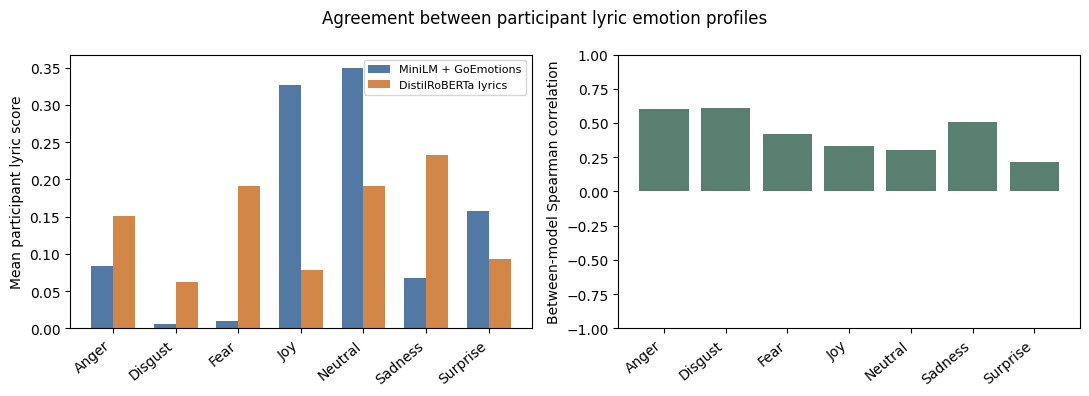

In [ ]:
def row_correlations(x,y):
    x=np.asarray(x,dtype=float); y=np.asarray(y,dtype=float)
    x=x-x.mean(axis=-1,keepdims=True); y=y-y.mean(axis=-1,keepdims=True)
    den=np.sqrt(np.sum(x*x,axis=-1)*np.sum(y*y,axis=-1))
    return np.divide(np.sum(x*y,axis=-1),den,out=np.full(den.shape,np.nan),where=den>0)

def bootstrap_rho(x,y,rng,repeats,batch_size=32):
    x=np.asarray(x,dtype=float); y=np.asarray(y,dtype=float); result=np.empty(repeats)
    for start in range(0,repeats,batch_size):
        end=min(start+batch_size,repeats)
        idx=rng.integers(0,len(x),size=(end-start,len(x)))
        result[start:end]=row_correlations(rankdata(x[idx],axis=1),rankdata(y[idx],axis=1))
    assert np.isfinite(result).all(), 'A bootstrap sample has constant scores; inspect the model outputs.'
    return result

def bootstrap_mean(values,rng,repeats,batch_size=32):
    values=np.asarray(values); result=np.empty(repeats)
    for start in range(0,repeats,batch_size):
        end=min(start+batch_size,repeats)
        idx=rng.integers(0,len(values),size=(end-start,len(values)))
        result[start:end]=values[idx].mean(axis=1)
    return result

agreement_rows=[]; top_rows=[]

for level,a,b in [('distinct_lyric',old_lyrics[LCOLS].to_numpy(),new_scores),
                   ('participant',features[LCOLS].to_numpy(),alternative[LCOLS].to_numpy())]:
    for j,label in enumerate(LABELS):
        shift=b[:,j]-a[:,j]
        row={'level':level,'emotion':label,'n':len(a),
            'pearson_r':float(row_correlations(a[:,j],b[:,j])),
            'spearman_rho':float(spearmanr(a[:,j],b[:,j]).statistic),
            'minilm_mean':float(a[:,j].mean()),'distilroberta_mean':float(b[:,j].mean()),
            'mean_signed_shift':float(shift.mean()),'mean_absolute_score_difference':float(np.abs(shift).mean())}
        if level=='participant':
            lo,hi=np.quantile(bootstrap_mean(shift,np.random.default_rng(3100+j),BOOTSTRAPS),[.025,.975])
            row.update(shift_ci_low=float(lo),shift_ci_high=float(hi))
        agreement_rows.append(row)
    top_a=a.argmax(axis=1); top_b=b.argmax(axis=1)
    matrix=pd.crosstab(pd.Categorical.from_codes(top_a,LABELS),pd.Categorical.from_codes(top_b,LABELS),dropna=False)
    matrix.index.name='MiniLM top category'; matrix.columns.name='DistilRoBERTa top category'
    matrix.to_csv(RESULTS/'analysis'/('model_top_category_counts_'+level+'.csv'))
    top_rows.append({'level':level,'n':len(a),'top_category_agreement':float(np.mean(top_a==top_b)),
                     'cohen_kappa':float(cohen_kappa_score(top_a,top_b,labels=range(7)))})

agreement=pd.DataFrame(agreement_rows); top_agreement=pd.DataFrame(top_rows)
agreement.to_csv(RESULTS/'analysis/model_score_agreement.csv',index=False)
top_agreement.to_csv(RESULTS/'analysis/model_top_category_agreement.csv',index=False)

display(agreement); display(top_agreement)

plot=agreement[agreement.level.eq('participant')].set_index('emotion').loc[LABELS]
fig,axes=plt.subplots(1,2,figsize=(11,4))
pos=np.arange(7); width=.35
axes[0].bar(pos-width/2,plot.minilm_mean,width,label='MiniLM + GoEmotions',color='#5279a4')
axes[0].bar(pos+width/2,plot.distilroberta_mean,width,label='DistilRoBERTa lyrics',color='#d28748')
axes[0].set_ylabel('Mean participant lyric score'); axes[0].legend(fontsize=8)
axes[0].set_xticks(pos,[s.title() for s in LABELS],rotation=40,ha='right')
axes[1].bar(pos,plot.spearman_rho,color='#587f70'); axes[1].set_ylim(-1,1)
axes[1].set_ylabel('Between-model Spearman correlation')
axes[1].set_xticks(pos,[s.title() for s in LABELS],rotation=40,ha='right')
fig.suptitle('Agreement between participant lyric emotion profiles')
fig.tight_layout(); save_figure(fig,'lyric_model_agreement')
CHECK_STATUS['model_agreement']=True


## 9. Repeat group effects and tweet–lyric relationships
Positive Cliff's delta means higher scores in the depression-labelled group. Group effect intervals
resample participants independently within each group. Matching Spearman correlations measure whether
participants with higher tweet scores also have higher lyric scores for the same category. They do not
compare an individual tweet with a particular song in time. Both pipelines are shown, with the same
tests/correction families. Changes in significance alone are not formal tests of a pipeline difference.


MiniLM_GoEmotions group tweet:   0%|          | 0/7 [00:00<?, ?it/s]

MiniLM_GoEmotions group lyric:   0%|          | 0/7 [00:00<?, ?it/s]

MiniLM_GoEmotions matching all:   0%|          | 0/7 [00:00<?, ?it/s]

MiniLM_GoEmotions matching control:   0%|          | 0/7 [00:00<?, ?it/s]

MiniLM_GoEmotions matching depression:   0%|          | 0/7 [00:00<?, ?it/s]

...

DistilRoBERTa_lyrics matching all:   0%|          | 0/7 [00:00<?, ?it/s]

DistilRoBERTa_lyrics matching control:   0%|          | 0/7 [00:00<?, ?it/s]

DistilRoBERTa_lyrics matching depression:   0%|          | 0/7 [00:00<?, ?it/s]

,pipeline,source,emotion,depression_n,control_n,depression_mean,control_mean,cliffs_delta,ci_low,ci_high,p,q_BH_14
7,MiniLM_GoEmotions,lyric,anger,754,3502,0.077527,0.085243,-0.074962,-0.118362,-0.033539,0.001222,0.002139
8,MiniLM_GoEmotions,lyric,disgust,754,3502,0.006213,0.005833,0.000089,-0.049081,0.046170,0.996963,0.996963
9,MiniLM_GoEmotions,lyric,fear,754,3502,0.011410,0.009154,0.113308,0.066425,0.159958,0.000001,0.000002
10,MiniLM_GoEmotions,lyric,joy,754,3502,0.330105,0.325828,0.027508,-0.019102,0.075068,0.235391,0.253498
11,MiniLM_GoEmotions,lyric,neutral,754,3502,0.342694,0.351632,-0.066899,-0.114071,-0.019849,0.003904,0.005465
12,MiniLM_GoEmotions,lyric,sadness,754,3502,0.073376,0.065654,0.073815,0.025387,0.120778,0.001452,0.002258
13,MiniLM_GoEmotions,lyric,surprise,754,3502,0.158674,0.156656,0.031346,-0.014408,0.079382,0.176319,0.205706
21,DistilRoBERTa_lyrics,lyric,anger,754,3502,0.139265,0.153509,-0.081508,-0.125731,-0.037185,0.000438,0.000876
22,DistilRoBERTa_lyrics,lyric,disgust,754,3502,0.058519,0.063338,-0.070652,-0.118567,-0.024787,0.002306,0.003587
23,DistilRoBERTa_lyrics,lyric,fear,754,3502,0.205817,0.187400,0.058120,0.011322,0.103710,0.012172,0.015492


,pipeline,group,emotion,n,rho,ci_low,ci_high,p,q_BH_7
0,MiniLM_GoEmotions,all,anger,4256,0.307433,0.278197,0.336722,7.675738e-94,5.373017e-93
1,MiniLM_GoEmotions,all,disgust,4256,0.212383,0.185040,0.241371,1.325864e-44,4.640525e-44
2,MiniLM_GoEmotions,all,fear,4256,0.117799,0.088737,0.147431,1.262161e-14,2.945042e-14
3,MiniLM_GoEmotions,all,joy,4256,0.045421,0.015751,0.076790,3.038178e-03,4.253449e-03
4,MiniLM_GoEmotions,all,neutral,4256,0.028259,-0.001747,0.060038,6.527381e-02,6.527381e-02
5,MiniLM_GoEmotions,all,sadness,4256,0.115042,0.082634,0.145096,5.155207e-14,9.021612e-14
6,MiniLM_GoEmotions,all,surprise,4256,0.040679,0.008915,0.069791,7.951318e-03,9.276538e-03
21,DistilRoBERTa_lyrics,all,anger,4256,0.258146,0.227796,0.286902,9.321061e-66,6.524743e-65
22,DistilRoBERTa_lyrics,all,disgust,4256,0.186256,0.157988,0.215630,1.583381e-34,5.541833e-34
23,DistilRoBERTa_lyrics,all,fear,4256,0.057217,0.029424,0.089805,1.879686e-04,3.289450e-04


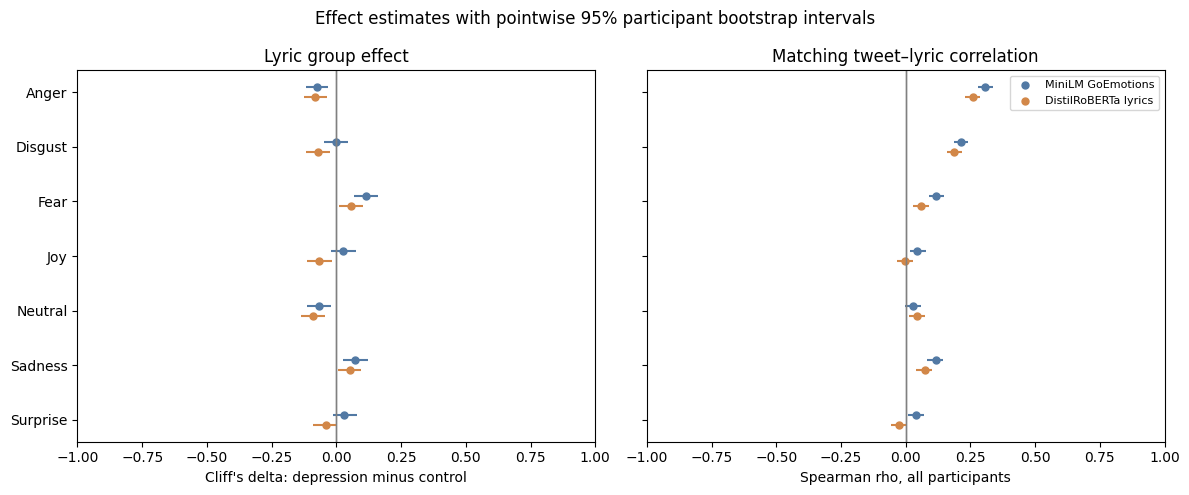

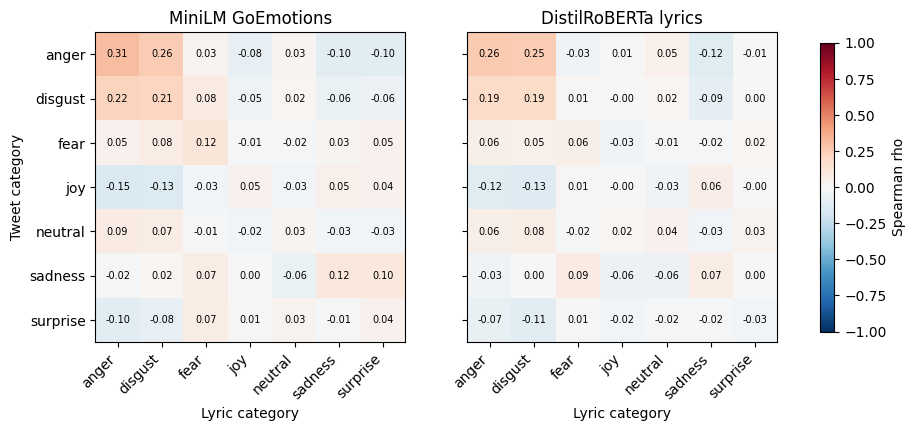

In [ ]:
def cliff_delta(dep,ctrl):
    return float(2*mannwhitneyu(dep,ctrl,alternative='two-sided').statistic/(len(dep)*len(ctrl))-1)

def bootstrap_cliff(dep,ctrl,rng,repeats,batch_size=24):
    dep=np.asarray(dep); ctrl=np.asarray(ctrl); nd=len(dep); nc=len(ctrl)
    result=np.empty(repeats)
    for start in range(0,repeats,batch_size):
        end=min(start+batch_size,repeats)
        a=dep[rng.integers(0,nd,size=(end-start,nd))]
        b=ctrl[rng.integers(0,nc,size=(end-start,nc))]
        ranks=rankdata(np.concatenate([a,b],axis=1),axis=1)
        u=ranks[:,:nd].sum(axis=1)-nd*(nd+1)/2
        result[start:end]=2*u/(nd*nc)-1
    return result

group_rows=[]; matching_rows=[]; matrix_rows=[]
for pipeline,data in PIPELINES.items():
    dep=data.disorder.eq('depression').to_numpy()
    for index,(source,cols) in enumerate([('tweet',TCOLS),('lyric',LCOLS)]):
        for j,(label,col) in enumerate(tqdm(list(zip(LABELS,cols)),desc=pipeline+' group '+source)):
            a=data.loc[dep,col].to_numpy(); b=data.loc[~dep,col].to_numpy()
            test=mannwhitneyu(a,b,alternative='two-sided')
            lo,hi=np.quantile(bootstrap_cliff(a,b,np.random.default_rng(4100+index*7+j),BOOTSTRAPS),[.025,.975])
            group_rows.append({'pipeline':pipeline,'source':source,'emotion':label,
                'depression_n':len(a),'control_n':len(b),'depression_mean':float(a.mean()),'control_mean':float(b.mean()),
                'cliffs_delta':cliff_delta(a,b),'ci_low':float(lo),'ci_high':float(hi),'p':float(test.pvalue)})
    for group,mask in [('all',np.ones(len(data),dtype=bool)),('control',~dep),('depression',dep)]:
        sub=data.loc[mask]
        for j,(label,tc,lc) in enumerate(tqdm(list(zip(LABELS,TCOLS,LCOLS)),desc=pipeline+' matching '+group)):
            test=spearmanr(sub[tc],sub[lc])
            seed=5100+j+100*['all','control','depression'].index(group)
            lo,hi=np.quantile(bootstrap_rho(sub[tc],sub[lc],np.random.default_rng(seed),BOOTSTRAPS),[.025,.975])
            matching_rows.append({'pipeline':pipeline,'group':group,'emotion':label,'n':len(sub),
                'rho':float(test.statistic),'ci_low':float(lo),'ci_high':float(hi),'p':float(test.pvalue)})
        for i,tc in enumerate(TCOLS):
            for j,lc in enumerate(LCOLS):
                matrix_rows.append({'pipeline':pipeline,'group':group,'tweet_emotion':LABELS[i],
                    'lyric_emotion':LABELS[j],'n':len(sub),'rho':float(spearmanr(sub[tc],sub[lc]).statistic)})

group_tests=pd.DataFrame(group_rows); matching=pd.DataFrame(matching_rows)

for _,idx in group_tests.groupby('pipeline').groups.items():
    group_tests.loc[idx,'q_BH_14']=multipletests(group_tests.loc[idx,'p'],method='fdr_bh')[1]

for _,idx in matching.groupby(['pipeline','group']).groups.items():
    matching.loc[idx,'q_BH_7']=multipletests(matching.loc[idx,'p'],method='fdr_bh')[1]

group_tests.to_csv(RESULTS/'analysis/emotion_group_tests.csv',index=False)
matching.to_csv(RESULTS/'analysis/matching_emotion_correlations.csv',index=False)
pd.DataFrame(matrix_rows).to_csv(RESULTS/'analysis/cross_source_correlations.csv',index=False)
saved_groups=pd.read_csv(INPUT/'original/analysis/emotion_group_tests.csv')

for row in group_tests[group_tests.pipeline.eq('MiniLM_GoEmotions')].itertuples():
    old=saved_groups[(saved_groups.source==row.source)&(saved_groups.category==row.emotion)].iloc[0]
    assert abs(row.cliffs_delta-old.delta)<1e-12 and abs(row.p-old.p)<1e-12 and abs(row.q_BH_14-old.q)<1e-12

saved_matching=pd.read_csv(INPUT/'original/analysis/matching_emotion_correlations.csv')

for row in matching[matching.pipeline.eq('MiniLM_GoEmotions')].itertuples():
    old=saved_matching[(saved_matching.group==row.group)&(saved_matching.category==row.emotion)].iloc[0]
    assert abs(row.rho-old.rho)<1e-12

display(group_tests[group_tests.source.eq('lyric')])

display(matching[matching.group.eq('all')])

fig,axes=plt.subplots(1,2,figsize=(12,5),sharey=True)
pos=np.arange(7)

for offset,(pipeline,color) in enumerate([('MiniLM_GoEmotions','#5279a4'),('DistilRoBERTa_lyrics','#d28748')]):
    for ax,table,value,title in [(axes[0],group_tests[group_tests.source.eq('lyric')],'cliffs_delta','Lyric group effect'),
                                  (axes[1],matching[matching.group.eq('all')],'rho','Matching tweet–lyric correlation')]:
        sub=table[table.pipeline.eq(pipeline)].set_index('emotion').loc[LABELS]
        yy=pos+(offset-.5)*.18
        ax.hlines(yy,sub.ci_low,sub.ci_high,color=color,lw=1.5)
        ax.scatter(sub[value],yy,color=color,label=pipeline.replace('_',' '),s=25)
        ax.axvline(0,color='grey',lw=1); ax.set_title(title); ax.set_xlim(-1,1)
axes[0].set_yticks(pos,[s.title() for s in LABELS]); axes[0].invert_yaxis()
axes[0].set_xlabel("Cliff's delta: depression minus control")
axes[1].set_xlabel('Spearman rho, all participants'); axes[1].legend(fontsize=8)
fig.suptitle('Effect estimates with pointwise 95% participant bootstrap intervals')
fig.tight_layout(); save_figure(fig,'group_effects_and_matching_correlations')
fig,axes=plt.subplots(1,2,figsize=(11,5),sharey=True)
matrix_table=pd.DataFrame(matrix_rows)

for ax,pipeline in zip(axes,PIPELINES):
    sub=matrix_table[(matrix_table.pipeline==pipeline)&(matrix_table.group=='all')]
    matrix=sub.pivot(index='tweet_emotion',columns='lyric_emotion',values='rho').loc[LABELS,LABELS]
    image=ax.imshow(matrix,vmin=-1,vmax=1,cmap='RdBu_r')
    for i in range(7):
        for j in range(7): ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center',fontsize=7)
    ax.set_xticks(range(7),LABELS,rotation=45,ha='right'); ax.set_yticks(range(7),LABELS)
    ax.set_xlabel('Lyric category'); ax.set_title(pipeline.replace('_',' '))

axes[0].set_ylabel('Tweet category'); fig.colorbar(image,ax=axes.ravel().tolist(),label='Spearman rho',shrink=.75)
save_figure(fig,'tweet_lyric_correlation_matrices')
CHECK_STATUS['group_effects_and_relationships']=True


## 10. Does correspondence differ between the two participant groups?
This repeats the formal group-difference check with both lyric pipelines. A positive difference means
the matching correlation is more positive in the depression-labelled group. Approximate centred-bootstrap
p-values allow each group to retain its own marginal score distributions. BH correction covers the same
ten measures per pipeline, including unchanged VAD. A changed q-value across models is not itself a test
that the models differ; it indicates sensitivity of the original inference.


MiniLM_GoEmotions group-correlation differences:   0%|          | 0/10 [00:00<?, ?it/s]

DistilRoBERTa_lyrics group-correlation differences:   0%|          | 0/10 [00:00<?, ?it/s]

,pipeline,measure,depression_n,control_n,depression_rho,control_rho,difference,ci_low,ci_high,p_approx,valid_bootstraps,q_BH_10
0,MiniLM_GoEmotions,anger,754,3502,0.178869,0.337606,-0.158737,-0.233477,-0.080570,0.001000,2000,0.009995
1,MiniLM_GoEmotions,disgust,754,3502,0.120269,0.234640,-0.114371,-0.191322,-0.037479,0.003998,2000,0.019990
2,MiniLM_GoEmotions,fear,754,3502,0.099945,0.102384,-0.002438,-0.079967,0.076911,0.949525,2000,0.949525
3,MiniLM_GoEmotions,joy,754,3502,0.018290,0.050100,-0.031810,-0.110571,0.053071,0.437781,2000,0.648565
4,MiniLM_GoEmotions,neutral,754,3502,0.006225,0.025563,-0.019338,-0.100967,0.058696,0.583708,2000,0.648565
5,MiniLM_GoEmotions,sadness,754,3502,0.125330,0.099789,0.025542,-0.055457,0.101380,0.571714,2000,0.648565
6,MiniLM_GoEmotions,surprise,754,3502,-0.017814,0.050012,-0.067826,-0.147471,0.008213,0.079960,2000,0.229885
7,MiniLM_GoEmotions,valence,754,3502,0.112698,0.179130,-0.066431,-0.144254,0.011429,0.095952,2000,0.229885
8,MiniLM_GoEmotions,arousal,754,3502,-0.084942,-0.020175,-0.064767,-0.145257,0.016572,0.114943,2000,0.229885
9,MiniLM_GoEmotions,dominance,754,3502,0.107736,0.076377,0.031360,-0.051064,0.109771,0.481759,2000,0.648565


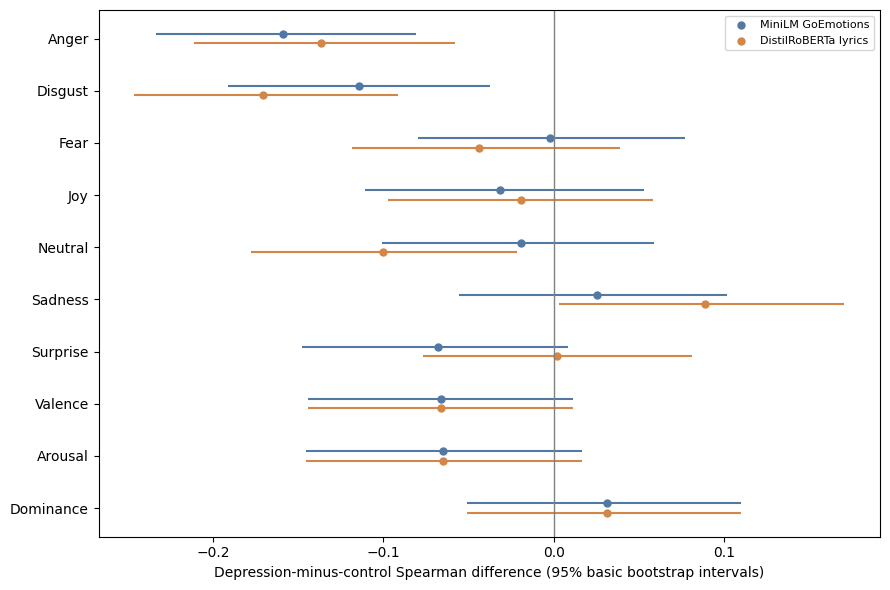

In [ ]:
PAIRS=[(label,tc,lc) for label,tc,lc in zip(LABELS,TCOLS,LCOLS)]+[
    (name,'tweet_'+d,'lyric_'+d) for name,d in [('valence','V'),('arousal','A'),('dominance','D')]]

diff_rows=[]

for pipeline,data in PIPELINES.items():
    dep=data[data.disorder.eq('depression')]; ctrl=data[data.disorder.eq('control')]
    for j,(name,tc,lc) in enumerate(tqdm(PAIRS,desc=pipeline+' group-correlation differences')):
        rd=float(spearmanr(dep[tc],dep[lc]).statistic); rc=float(spearmanr(ctrl[tc],ctrl[lc]).statistic)
        observed=rd-rc; rng=np.random.default_rng(20261020+j)
        boot=bootstrap_rho(dep[tc],dep[lc],rng,BOOTSTRAPS)-bootstrap_rho(ctrl[tc],ctrl[lc],rng,BOOTSTRAPS)
        centered=boot-observed
        lo,hi=observed-np.quantile(centered,[.975,.025])
        lower=(1+np.count_nonzero(centered<=observed))/(len(centered)+1)
        upper=(1+np.count_nonzero(centered>=observed))/(len(centered)+1)
        p=min(1.,2*min(lower,upper))
        diff_rows.append({'pipeline':pipeline,'measure':name,'depression_n':len(dep),'control_n':len(ctrl),
            'depression_rho':rd,'control_rho':rc,'difference':observed,
            'ci_low':float(lo),'ci_high':float(hi),'p_approx':float(p),'valid_bootstraps':len(boot)})

group_differences=pd.DataFrame(diff_rows)

for _,idx in group_differences.groupby('pipeline').groups.items():
    group_differences.loc[idx,'q_BH_10']=multipletests(group_differences.loc[idx,'p_approx'],method='fdr_bh')[1]

group_differences.to_csv(RESULTS/'analysis/group_correlation_differences.csv',index=False)
display(group_differences)
fig,ax=plt.subplots(figsize=(9,6)); pos=np.arange(len(PAIRS))

for i,(pipeline,color) in enumerate([('MiniLM_GoEmotions','#5279a4'),('DistilRoBERTa_lyrics','#d28748')]):
    sub=group_differences[group_differences.pipeline.eq(pipeline)].set_index('measure').loc[[p[0] for p in PAIRS]]
    yy=pos+(i-.5)*.18; ax.hlines(yy,sub.ci_low,sub.ci_high,color=color)
    ax.scatter(sub.difference,yy,color=color,label=pipeline.replace('_',' '),s=25)
ax.axvline(0,color='grey',lw=1); ax.set_yticks(pos,[p[0].title() for p in PAIRS]); ax.invert_yaxis()
ax.set_xlabel('Depression-minus-control Spearman difference (95% basic bootstrap intervals)')
ax.legend(fontsize=8); fig.tight_layout(); save_figure(fig,'group_correlation_difference_comparison')
CHECK_STATUS['group_correlation_differences']=True


## 11. Repeat classification on the saved folds
The five validation folds contain the exact original participants. Median imputation/scaling are fitted
only on training participants. Logistic regression uses balanced class weights and `C=1`. The secondary
random forest uses 300 trees, minimum leaf size 3 and balanced subsampling. All seeds are 42.

Original predictions are reused. The unchanged tweet-only and VAD-only baselines are also reused in the
alternative pipeline. Only sets containing lyric categories are refitted. Predictions are saved after
each completed fold; every participant is predicted by a model trained on the other folds.
No threshold is tuned: confusion counts use the classifier's original default threshold of 0.5.


In [ ]:
FEATURE_SETS={'VAD_both':VADCOLS,'category_tweets':TCOLS,'category_lyrics':LCOLS,
              'category_both':TCOLS+LCOLS,'VAD_and_categories':VADCOLS+TCOLS+LCOLS}

prototypes={'LR':make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),
    LogisticRegression(C=1,class_weight='balanced',max_iter=5000,random_state=SEED))}

if INCLUDE_RANDOM_FOREST:
    prototypes['RF']=make_pipeline(SimpleImputer(strategy='median'),
        RandomForestClassifier(n_estimators=300,min_samples_leaf=3,class_weight='balanced_subsample',random_state=SEED,n_jobs=2))

def cv_predictions(data,cols,model):
    X=data[cols].to_numpy(dtype=np.float64)
    yy=data.disorder.eq('depression').to_numpy(dtype=int); ff=data.fold.to_numpy(dtype=int)
    metadata={'code_version':CODE_VERSION,'model':model,'feature_columns':cols,'score_key':SCORE_KEY,
        'classifier':str(prototypes[model]),'packages':PACKAGE_VERSIONS,'participants':data.participant_id.tolist()}
    h=hashlib.sha256(json.dumps(metadata,sort_keys=True).encode())

    for array in [X,yy,ff]: h.update(np.ascontiguousarray(array).tobytes())
    key=h.hexdigest(); path=CACHE/('classifier_'+key+'.npz')
    probability=np.full(len(data),np.nan); predicted=np.full(len(data),-1,dtype=int); completed=np.zeros(5,dtype=bool)

    if path.exists():
        with np.load(path,allow_pickle=False) as state:
            assert str(state['key'])==key
            probability=state['probability'].copy(); predicted=state['predicted'].copy(); completed=state['completed'].copy()
        assert probability.shape==predicted.shape==(len(data),) and completed.shape==(5,)

    for fold in tqdm(range(1,6),desc=model+' '+str(len(cols))+' features',leave=False):
        validation=ff==fold; training=~validation
        assert set(yy[training])==set(yy[validation])=={0,1}
        if completed[fold-1]:
            assert np.isfinite(probability[validation]).all() and np.isin(predicted[validation],[0,1]).all()
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('error',ConvergenceWarning)
            fitted=clone(prototypes[model]).fit(X[training],yy[training])
        probability[validation]=fitted.predict_proba(X[validation])[:,1]
        predicted[validation]=fitted.predict(X[validation])
        completed[fold-1]=True
        save_npz(path,key=np.array(key),probability=probability,predicted=predicted,completed=completed)
    assert completed.all() and np.isfinite(probability).all() and ((probability>=0)&(probability<=1)).all()
    return pd.DataFrame({'participant_id':data.participant_id.to_numpy(),'fold':ff,'y':yy,
        'probability':probability,'predicted':predicted,'prediction_origin':'refitted_saved_folds','cache_key':key})

def original_predictions(name,model):
    part=old_oof[(old_oof.features==name)&(old_oof.model==model)].set_index('participant_id').loc[features.participant_id].reset_index()
    result=part[['participant_id','fold','y','probability','predicted']].copy()
    result['prediction_origin']='reused_original_OOF'; result['cache_key']='original'
    return result

prediction_parts=[]
for pipeline,data in PIPELINES.items():
    for name,cols in tqdm(list(FEATURE_SETS.items()),desc=pipeline+' classifiers'):
        for model in prototypes:
            reuse=pipeline=='MiniLM_GoEmotions' or name in ['VAD_both','category_tweets']
            part=original_predictions(name,model) if reuse else cv_predictions(data,cols,model)
            part['pipeline']=pipeline; part['features']=name; part['model']=model; part['feature_count']=len(cols)
            prediction_parts.append(part)
            pd.concat(prediction_parts,ignore_index=True).to_csv(RESULTS/'analysis/classification_oof.csv',index=False)

oof=pd.concat(prediction_parts,ignore_index=True)
assert not oof.duplicated(['pipeline','features','model','participant_id']).any()
CHECK_STATUS['classification_predictions']=True

print('Held-out predictions complete.')


MiniLM_GoEmotions classifiers:   0%|          | 0/5 [00:00<?, ?it/s]

DistilRoBERTa_lyrics classifiers:   0%|          | 0/5 [00:00<?, ?it/s]

LR 7 features:   0%|          | 0/5 [00:00<?, ?it/s]

RF 7 features:   0%|          | 0/5 [00:00<?, ?it/s]

LR 14 features:   0%|          | 0/5 [00:00<?, ?it/s]

RF 14 features:   0%|          | 0/5 [00:00<?, ?it/s]

LR 20 features:   0%|          | 0/5 [00:00<?, ?it/s]

RF 20 features:   0%|          | 0/5 [00:00<?, ?it/s]

Held-out predictions complete.


## 12. Compare performance and write the final results
Fold mean AUROC and its standard deviation match the earlier thesis reporting convention. Pooled AUROC,
average precision, sensitivity, specificity, precision and confusion counts use one held-out prediction
per participant. The paired bootstrap samples the **same participants** for both sets of predictions,
separately within depression/control labels.

The key comparisons are DistilRoBERTa-minus-MiniLM for lyric-containing feature sets, combined-minus-tweets
within each pipeline, and VAD-plus-categories minus categories within each pipeline. An interval containing
zero leaves the corresponding improvement uncertain; it does not establish equivalence. These intervals
condition on fixed OOF predictions and omit retraining variability. They are exploratory and unadjusted
for the full set of comparisons. The summary uses these qualifications automatically.


Performance intervals:   0%|          | 0/20 [00:00<?, ?it/s]

,pipeline,features,model,mean_fold_auroc,sd_fold_auroc,pooled_auroc,average_precision,sensitivity,specificity
0,DistilRoBERTa_lyrics,VAD_and_categories,LR,0.720687,0.021381,0.719465,0.323096,0.660477,0.651342
1,DistilRoBERTa_lyrics,VAD_and_categories,RF,0.729365,0.016955,0.728063,0.351400,0.131300,0.971445
2,DistilRoBERTa_lyrics,VAD_both,LR,0.641034,0.020906,0.641020,0.261920,0.587533,0.613649
3,DistilRoBERTa_lyrics,VAD_both,RF,0.637752,0.014316,0.637536,0.253061,0.063660,0.966876
4,DistilRoBERTa_lyrics,category_both,LR,0.716211,0.017228,0.715587,0.316635,0.645889,0.669046
5,DistilRoBERTa_lyrics,category_both,RF,0.717093,0.015606,0.715928,0.337637,0.144562,0.965448
6,DistilRoBERTa_lyrics,category_lyrics,LR,0.542786,0.025628,0.541429,0.192572,0.507958,0.570531
7,DistilRoBERTa_lyrics,category_lyrics,RF,0.568077,0.019160,0.567377,0.212834,0.027851,0.983724
8,DistilRoBERTa_lyrics,category_tweets,LR,0.715766,0.015253,0.714825,0.319565,0.644562,0.656482
9,DistilRoBERTa_lyrics,category_tweets,RF,0.706845,0.008943,0.706890,0.328446,0.169761,0.944889


,comparison,model,pipeline_a,features_a,pipeline_b,features_b,n,pooled_auroc_difference,ci_low,ci_high
0,distilroberta_minus_minilm_category_lyrics,LR,DistilRoBERTa_lyrics,category_lyrics,MiniLM_GoEmotions,category_lyrics,4256,-0.048224,-0.073101,-0.023999
1,distilroberta_minus_minilm_category_both,LR,DistilRoBERTa_lyrics,category_both,MiniLM_GoEmotions,category_both,4256,-0.004234,-0.010427,0.001873
2,distilroberta_minus_minilm_VAD_and_categories,LR,DistilRoBERTa_lyrics,VAD_and_categories,MiniLM_GoEmotions,VAD_and_categories,4256,-0.001284,-0.006556,0.004024
3,lyrics_increment_MiniLM_GoEmotions,LR,MiniLM_GoEmotions,category_both,MiniLM_GoEmotions,category_tweets,4256,0.004997,-0.000319,0.010656
4,VAD_increment_MiniLM_GoEmotions,LR,MiniLM_GoEmotions,VAD_and_categories,MiniLM_GoEmotions,category_both,4256,0.000928,-0.005405,0.006883
5,lyrics_increment_DistilRoBERTa_lyrics,LR,DistilRoBERTa_lyrics,category_both,DistilRoBERTa_lyrics,category_tweets,4256,0.000762,-0.004117,0.005754
6,VAD_increment_DistilRoBERTa_lyrics,LR,DistilRoBERTa_lyrics,VAD_and_categories,DistilRoBERTa_lyrics,category_both,4256,0.003878,-0.002312,0.010480
7,distilroberta_minus_minilm_category_lyrics,RF,DistilRoBERTa_lyrics,category_lyrics,MiniLM_GoEmotions,category_lyrics,4256,0.023054,-0.004983,0.051301
8,distilroberta_minus_minilm_category_both,RF,DistilRoBERTa_lyrics,category_both,MiniLM_GoEmotions,category_both,4256,-0.008981,-0.019155,0.000686
9,distilroberta_minus_minilm_VAD_and_categories,RF,DistilRoBERTa_lyrics,VAD_and_categories,MiniLM_GoEmotions,VAD_and_categories,4256,-0.003031,-0.010470,0.004591


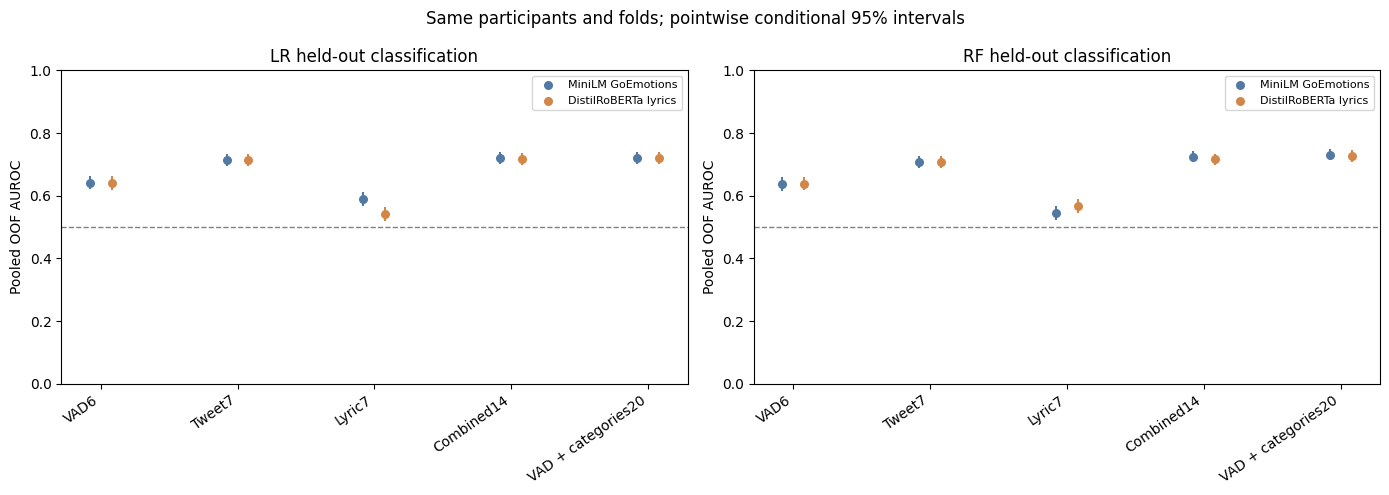

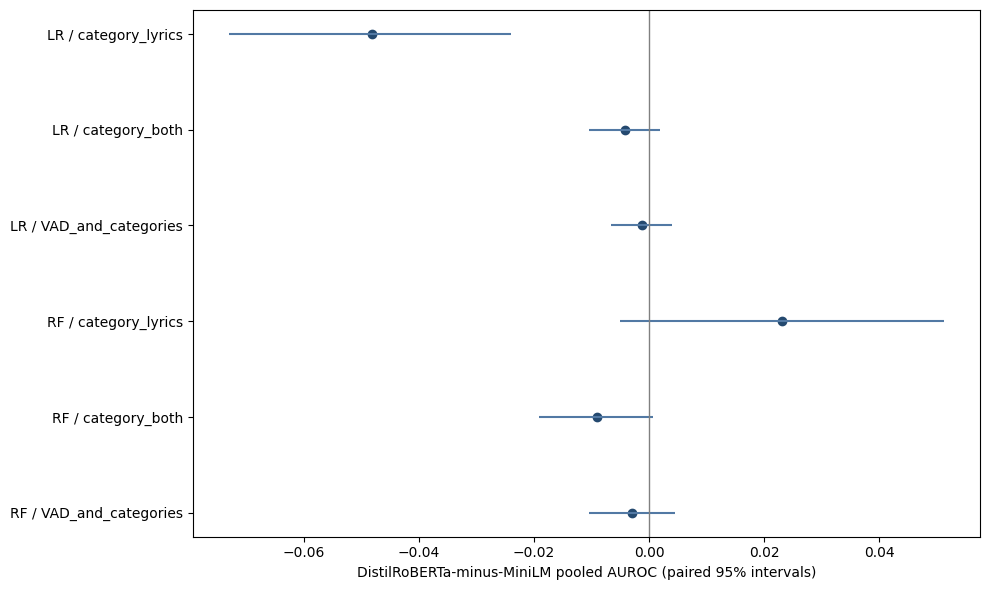

# Final lyric-model comparison

Completed all 7 checks on 4,256 participants, 47,204 participant-song rows and 30,392 distinct cleaned lyrics.
Original participant lyric means reconstructed with maximum absolute difference 1.67e-16.
Full DistilRoBERTa coverage: 14,908,265 content tokens in 43,705 chunks; zero tokens truncated.
Original tweet scores, VAD values, cohort and participant folds were kept fixed.

## Agreement between models
The following values measure agreement, not emotion accuracy.
distinct_lyric: top-category agreement 23.1%; Cohen kappa 0.085.
participant: top-category agreement 18.7%; Cohen kappa 0.054.
anger: participant Spearman rho 0.603; mean absolute score difference 0.0858; signed DistilRoBERTa-minus-MiniLM shift +0.0671.
disgust: participant Spearman rho 0.606; mean absolute score difference 0.0568; signed DistilRoBERTa-minus-MiniLM shift +0.0566.
fear: participant Spearman rho 0.423; mean absolute score difference 0.1814; signed DistilRoBERTa-minus-MiniLM shift +0.1811.
joy: participant Spearman rho 0.335; mean absolute score difference 0.2555; signed DistilRoBERTa-minus-MiniLM shift -0.2477.
neutral: participant Spearman rho 0.302; mean absolute score difference 0.1782; signed DistilRoBERTa-minus-MiniLM shift -0.1588.
sadness: participant Spearman rho 0.509; mean absolute score difference 0.1739; signed DistilRoBERTa-minus-MiniLM shift +0.1659.
surprise: participant Spearman rho 0.218; mean absolute score difference 0.0963; signed DistilRoBERTa-minus-MiniLM shift -0.0642.

## Classification performance
DistilRoBERTa_lyrics, LR, VAD_and_categories: fold mean AUROC 0.7207 +/- 0.0214; pooled AUROC 0.7195; sensitivity 66.0%; specificity 65.1%.
DistilRoBERTa_lyrics, RF, VAD_and_categories: fold mean AUROC 0.7294 +/- 0.0170; pooled AUROC 0.7281; sensitivity 13.1%; specificity 97.1%.
DistilRoBERTa_lyrics, LR, VAD_both: fold mean AUROC 0.6410 +/- 0.0209; pooled AUROC 0.6410; sensitivity 58.8%; specificity 61.4%.
DistilRoBERTa_lyrics, RF, VAD_both: fold mean AUROC 0.6378 +/- 0.0143; pooled AUROC 0.6375; sensitivity 6.4%; specificity 96.7%.
DistilRoBERTa_lyrics, LR, category_both: fold mean AUROC 0.7162 +/- 0.0172; pooled AUROC 0.7156; sensitivity 64.6%; specificity 66.9%.
DistilRoBERTa_lyrics, RF, category_both: fold mean AUROC 0.7171 +/- 0.0156; pooled AUROC 0.7159; sensitivity 14.5%; specificity 96.5%.
DistilRoBERTa_lyrics, LR, category_lyrics: fold mean AUROC 0.5428 +/- 0.0256; pooled AUROC 0.5414; sensitivity 50.8%; specificity 57.1%.
DistilRoBERTa_lyrics, RF, category_lyrics: fold mean AUROC 0.5681 +/- 0.0192; pooled AUROC 0.5674; sensitivity 2.8%; specificity 98.4%.
DistilRoBERTa_lyrics, LR, category_tweets: fold mean AUROC 0.7158 +/- 0.0153; pooled AUROC 0.7148; sensitivity 64.5%; specificity 65.6%.
DistilRoBERTa_lyrics, RF, category_tweets: fold mean AUROC 0.7068 +/- 0.0089; pooled AUROC 0.7069; sensitivity 17.0%; specificity 94.5%.
MiniLM_GoEmotions, LR, VAD_and_categories: fold mean AUROC 0.7217 +/- 0.0199; pooled AUROC 0.7207; sensitivity 66.6%; specificity 65.9%.
MiniLM_GoEmotions, RF, VAD_and_categories: fold mean AUROC 0.7321 +/- 0.0233; pooled AUROC 0.7311; sensitivity 14.3%; specificity 96.9%.
MiniLM_GoEmotions, LR, VAD_both: fold mean AUROC 0.6410 +/- 0.0209; pooled AUROC 0.6410; sensitivity 58.8%; specificity 61.4%.
MiniLM_GoEmotions, RF, VAD_both: fold mean AUROC 0.6378 +/- 0.0143; pooled AUROC 0.6375; sensitivity 6.4%; specificity 96.7%.
MiniLM_GoEmotions, LR, category_both: fold mean AUROC 0.7206 +/- 0.0156; pooled AUROC 0.7198; sensitivity 65.3%; specificity 66.4%.
MiniLM_GoEmotions, RF, category_both: fold mean AUROC 0.7264 +/- 0.0190; pooled AUROC 0.7249; sensitivity 14.6%; specificity 96.4%.
MiniLM_GoEmotions, LR, category_lyrics: fold mean AUROC 0.5902 +/- 0.0165; pooled AUROC 0.5897; sensitivity 52.9%; specificity 61.4%.
MiniLM_GoEmotions, RF, category_lyrics: fold mean AUROC 0.5447 +/- 0.0192; pooled AUROC 0.5443; sensitivity 2.9%; specificity 98.1%.
MiniLM_GoEmotions, LR, category_tweets: fold mean AUROC 0.7158 +/- 0.0153; pooled AUROC 0.7148; sensitivity 64.5%; specificity 65.6%.
MiniLM_GoEmotions, RF, category_tweets: fold mean AUROC 0.7068 +/- 0.0089; pooled AUROC 0.7069; sensitivity 17.0%; specificity 94.5%.

## Paired prediction changes
Positive values favour the first pipeline/feature set. Intervals are exploratory, pointwise and conditional on fixed OOF predictions.
LR, distilroberta_minus_minilm_category_lyrics: AUROC change -0.0482, 95% CI [-0.0731, -0.0240]. The conditional interval lies below zero.
LR, distilroberta_minus_minilm_category_both: AUROC change -0.0042, 95% CI [-0.0104, 0.0019]. The interval includes zero; the change remains uncertain, without establishing equivalence.
LR, distilroberta_minus_minilm_VAD_and_categories: AUROC change -0.0013, 95% CI [-0.0066, 0.0040]. The interval includes zero; the change remains uncertain, without establishing equivalence.
LR, lyrics_increment_MiniLM_GoEmotions: AUROC change +0.0050, 95% CI [-0.0003, 0.0107]. The interval includes zero; the change remains uncertain, without establishing equivalence.
LR, VAD_increment_MiniLM_GoEmotions: AUROC change +0.0009, 95% CI [-0.0054, 0.0069]. The interval includes zero; the change remains uncertain, without establishing equivalence.
LR, lyrics_increment_DistilRoBERTa_lyrics: AUROC change +0.0008, 95% CI [-0.0041, 0.0058]. The interval includes zero; the change remains uncertain, without establishing equivalence.
LR, VAD_increment_DistilRoBERTa_lyrics: AUROC change +0.0039, 95% CI [-0.0023, 0.0105]. The interval includes zero; the change remains uncertain, without establishing equivalence.
RF, distilroberta_minus_minilm_category_lyrics: AUROC change +0.0231, 95% CI [-0.0050, 0.0513]. The interval includes zero; the change remains uncertain, without establishing equivalence.
RF, distilroberta_minus_minilm_category_both: AUROC change -0.0090, 95% CI [-0.0192, 0.0007]. The interval includes zero; the change remains uncertain, without establishing equivalence.
RF, distilroberta_minus_minilm_VAD_and_categories: AUROC change -0.0030, 95% CI [-0.0105, 0.0046]. The interval includes zero; the change remains uncertain, without establishing equivalence.
RF, lyrics_increment_MiniLM_GoEmotions: AUROC change +0.0180, 95% CI [0.0068, 0.0295]. The conditional interval lies above zero.
RF, VAD_increment_MiniLM_GoEmotions: AUROC change +0.0062, 95% CI [-0.0003, 0.0126]. The interval includes zero; the change remains uncertain, without establishing equivalence.
RF, lyrics_increment_DistilRoBERTa_lyrics: AUROC change +0.0090, 95% CI [-0.0015, 0.0205]. The interval includes zero; the change remains uncertain, without establishing equivalence.
RF, VAD_increment_DistilRoBERTa_lyrics: AUROC change +0.0121, 95% CI [0.0050, 0.0194]. The conditional interval lies above zero.

## Tweet–lyric correspondence and group differences
The tables below compare the same people. Separate exploratory BH families apply within each pipeline; differences in q-values are not formal between-pipeline tests.
MiniLM_GoEmotions: measures with group-correlation difference q<0.05 in the ten-test family: anger, disgust.
MiniLM_GoEmotions, all: matching sadness rho 0.115, CI [0.083, 0.145].
MiniLM_GoEmotions, control: matching sadness rho 0.100, CI [0.065, 0.133].
MiniLM_GoEmotions, depression: matching sadness rho 0.125, CI [0.056, 0.193].
DistilRoBERTa_lyrics: measures with group-correlation difference q<0.05 in the ten-test family: anger, disgust, neutral.
DistilRoBERTa_lyrics, all: matching sadness rho 0.073, CI [0.040, 0.103].
DistilRoBERTa_lyrics, control: matching sadness rho 0.050, CI [0.016, 0.084].
DistilRoBERTa_lyrics, depression: matching sadness rho 0.139, CI [0.068, 0.205].

## Interpretation limits
Model agreement cannot establish which predictor is more accurate on lyrics. The models differ in training data, tokenizer and context/chunk boundaries, so this compares scoring pipelines rather than architecture alone.
All new results are post-primary exploratory checks. Participant resampling omits full retraining, shared-song clustering and social dependence. Fixed participant folds do not guarantee unseen songs/artists or external-population performance.
Dataset labels are disclosure-derived and not independently clinically validated. Shared songs are not verified listening. The mixed-model analysis is a sensitivity check alongside the primary same-model analysis.

## Main files
- analysis/model_score_agreement.csv and model_top_category_agreement.csv
- analysis/emotion_group_tests.csv and matching_emotion_correlations.csv
- analysis/group_correlation_differences.csv
- analysis/classification_summary.csv and paired_auroc_comparisons.csv
- analysis/classification_oof.csv and classification_folds.csv
- figures/: publication-ready PDF figures and PNG previews

The thesis text and PDF have not been edited.


COMPLETE. Downloaded comparison results: /content/drive/MyDrive/Thesis_DistilRoBERTa_Comparison/Thesis_DistilRoBERTa_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def auc_bootstrap(y,p,rng,repeats,q=None,batch_size=32):
    yy=np.asarray(y); p=np.asarray(p,dtype=float)
    positive=np.flatnonzero(yy==1); negative=np.flatnonzero(yy==0); npos=len(positive); nneg=len(negative)
    assert npos>0 and nneg>0
    if q is not None: q=np.asarray(q,dtype=float); assert q.shape==p.shape
    result=np.empty(repeats)
    def auc_rows(scores):
        ranks=rankdata(scores,axis=1)
        return (ranks[:,:npos].sum(axis=1)-npos*(npos+1)/2)/(npos*nneg)
    for start in range(0,repeats,batch_size):
        end=min(start+batch_size,repeats)
        idx=np.concatenate([rng.choice(positive,(end-start,npos),replace=True),rng.choice(negative,(end-start,nneg),replace=True)],axis=1)
        result[start:end]=auc_rows(p[idx])
        if q is not None: result[start:end]-=auc_rows(q[idx])
    return result

def metrics(data):
    yy=data.y.to_numpy(); probability=data.probability.to_numpy(); predicted=data.predicted.to_numpy()
    tn,fp,fn,tp=confusion_matrix(yy,predicted,labels=[0,1]).ravel()
    sensitivity=tp/(tp+fn); specificity=tn/(tn+fp)
    return {'n':len(data),'depression_n':int(yy.sum()),'prevalence':float(yy.mean()),
        'pooled_auroc':float(roc_auc_score(yy,probability)),'average_precision':float(average_precision_score(yy,probability)),
        'balanced_accuracy':float((sensitivity+specificity)/2),'sensitivity':float(sensitivity),'specificity':float(specificity),
        'precision':float(tp/(tp+fp)) if tp+fp else 0.,'true_negative':int(tn),'false_positive':int(fp),
        'false_negative':int(fn),'true_positive':int(tp)}

summary_rows=[]; fold_rows=[]

for i,((pipeline,name,model),data) in enumerate(tqdm(list(oof.groupby(['pipeline','features','model'])),desc='Performance intervals')):
    ff=[]
    for fold,part in data.groupby('fold'):
        row=dict(pipeline=pipeline,features=name,model=model,fold=int(fold),**metrics(part))
        ff.append(row); fold_rows.append(row)
    lo,hi=np.quantile(auc_bootstrap(data.y,data.probability,np.random.default_rng(7100+i),BOOTSTRAPS),[.025,.975])
    summary_rows.append(dict(pipeline=pipeline,features=name,model=model,feature_count=int(data.feature_count.iloc[0]),
        mean_fold_auroc=float(np.mean([r['pooled_auroc'] for r in ff])),sd_fold_auroc=float(np.std([r['pooled_auroc'] for r in ff],ddof=1)),
        mean_fold_balanced_accuracy=float(np.mean([r['balanced_accuracy'] for r in ff])),
        sd_fold_balanced_accuracy=float(np.std([r['balanced_accuracy'] for r in ff],ddof=1)),
        ci_low=float(lo),ci_high=float(hi),**metrics(data)))
classification_summary=pd.DataFrame(summary_rows)
classification_summary.to_csv(RESULTS/'analysis/classification_summary.csv',index=False)
pd.DataFrame(fold_rows).to_csv(RESULTS/'analysis/classification_folds.csv',index=False)

def get_prediction(pipeline,name,model):
    part=oof[(oof.pipeline==pipeline)&(oof.features==name)&(oof.model==model)].sort_values('participant_id').reset_index(drop=True)
    assert len(part)==4256 and part.participant_id.is_unique
    return part

paired_rows=[]

def compare(label,pipeline_a,name_a,pipeline_b,name_b,model):
    a=get_prediction(pipeline_a,name_a,model); b=get_prediction(pipeline_b,name_b,model)
    assert a.participant_id.tolist()==b.participant_id.tolist() and np.array_equal(a.y,b.y) and np.array_equal(a.fold,b.fold)
    estimate=roc_auc_score(a.y,a.probability)-roc_auc_score(b.y,b.probability)
    lo,hi=np.quantile(auc_bootstrap(a.y,a.probability,np.random.default_rng(8100+len(paired_rows)),BOOTSTRAPS,q=b.probability),[.025,.975])
    paired_rows.append({'comparison':label,'model':model,'pipeline_a':pipeline_a,'features_a':name_a,
        'pipeline_b':pipeline_b,'features_b':name_b,'n':len(a),'pooled_auroc_difference':float(estimate),
        'ci_low':float(lo),'ci_high':float(hi)})

for model in prototypes:
    for name in ['category_lyrics','category_both','VAD_and_categories']:
        compare('distilroberta_minus_minilm_'+name,'DistilRoBERTa_lyrics',name,'MiniLM_GoEmotions',name,model)
    for pipeline in PIPELINES:
        compare('lyrics_increment_'+pipeline,pipeline,'category_both',pipeline,'category_tweets',model)
        compare('VAD_increment_'+pipeline,pipeline,'VAD_and_categories',pipeline,'category_both',model)

paired=pd.DataFrame(paired_rows)
paired.to_csv(RESULTS/'analysis/paired_auroc_comparisons.csv',index=False)
display(classification_summary[['pipeline','features','model','mean_fold_auroc','sd_fold_auroc','pooled_auroc','average_precision','sensitivity','specificity']])
display(paired)

fig,axes=plt.subplots(1,len(prototypes),figsize=(7*len(prototypes),5),squeeze=False)
names=list(FEATURE_SETS); pos=np.arange(len(names))

for ax,model in zip(axes.ravel(),prototypes):
    for i,(pipeline,color) in enumerate([('MiniLM_GoEmotions','#5279a4'),('DistilRoBERTa_lyrics','#d28748')]):
        sub=classification_summary[(classification_summary.pipeline==pipeline)&(classification_summary.model==model)].set_index('features').loc[names]
        xx=pos+(i-.5)*.16
        ax.vlines(xx,sub.ci_low,sub.ci_high,color=color)
        ax.scatter(xx,sub.pooled_auroc,color=color,label=pipeline.replace('_',' '),s=30)
    ax.axhline(.5,color='grey',ls='--',lw=1); ax.set_ylim(0,1)
    ax.set_xticks(pos,['VAD6','Tweet7','Lyric7','Combined14','VAD + categories20'],rotation=35,ha='right')
    ax.set_title(model+' held-out classification'); ax.set_ylabel('Pooled OOF AUROC'); ax.legend(fontsize=8)

fig.suptitle('Same participants and folds; pointwise conditional 95% intervals')
fig.tight_layout(); save_figure(fig,'classification_model_comparison')
fig,ax=plt.subplots(figsize=(10,6))
plot=paired[paired.comparison.str.startswith('distilroberta_minus_minilm')].copy()
positions=np.arange(len(plot)); ax.hlines(positions,plot.ci_low,plot.ci_high,color='#5279a4')
ax.scatter(plot.pooled_auroc_difference,positions,color='#24496f')
ax.axvline(0,color='grey',lw=1)
ax.set_yticks(positions,[r.model+' / '+r.features_a for r in plot.itertuples()]); ax.invert_yaxis()
ax.set_xlabel('DistilRoBERTa-minus-MiniLM pooled AUROC (paired 95% intervals)')
fig.tight_layout(); save_figure(fig,'paired_prediction_changes')
CHECK_STATUS['performance_comparisons']=True

required=['full_lyric_scoring','participant_profiles','model_agreement','group_effects_and_relationships',
          'group_correlation_differences','classification_predictions','performance_comparisons']
assert all(CHECK_STATUS.get(name) for name in required)

lines=['# Final lyric-model comparison', '',
    f'Completed all {len(required)} checks on 4,256 participants, 47,204 participant-song rows and 30,392 distinct cleaned lyrics.',
    f'Original participant lyric means reconstructed with maximum absolute difference {old_reproduction_error:.2e}.',
    f'Full DistilRoBERTa coverage: {int(token_counts.sum()):,} content tokens in {len(owners):,} chunks; zero tokens truncated.',
    'Original tweet scores, VAD values, cohort and participant folds were kept fixed.', '',
    '## Agreement between models',
    'The following values measure agreement, not emotion accuracy.']

for row in top_agreement.itertuples():
    lines.append(f'{row.level}: top-category agreement {row.top_category_agreement:.1%}; Cohen kappa {row.cohen_kappa:.3f}.')

for row in agreement[agreement.level.eq('participant')].itertuples():
    lines.append(f'{row.emotion}: participant Spearman rho {row.spearman_rho:.3f}; mean absolute score difference {row.mean_absolute_score_difference:.4f}; signed DistilRoBERTa-minus-MiniLM shift {row.mean_signed_shift:+.4f}.')

lines+=['','## Classification performance']

for row in classification_summary.itertuples():
    lines.append(f'{row.pipeline}, {row.model}, {row.features}: fold mean AUROC {row.mean_fold_auroc:.4f} +/- {row.sd_fold_auroc:.4f}; pooled AUROC {row.pooled_auroc:.4f}; sensitivity {row.sensitivity:.1%}; specificity {row.specificity:.1%}.')

lines+=['','## Paired prediction changes',
    'Positive values favour the first pipeline/feature set. Intervals are exploratory, pointwise and conditional on fixed OOF predictions.']

for row in paired.itertuples():
    if row.ci_low>0: interpretation='The conditional interval lies above zero.'
    elif row.ci_high<0: interpretation='The conditional interval lies below zero.'
    else: interpretation='The interval includes zero; the change remains uncertain, without establishing equivalence.'
    lines.append(f'{row.model}, {row.comparison}: AUROC change {row.pooled_auroc_difference:+.4f}, 95% CI [{row.ci_low:.4f}, {row.ci_high:.4f}]. {interpretation}')

lines+=['','## Tweet–lyric correspondence and group differences',
    'The tables below compare the same people. Separate exploratory BH families apply within each pipeline; differences in q-values are not formal between-pipeline tests.']

for pipeline in PIPELINES:
    significant=group_differences[(group_differences.pipeline==pipeline)&(group_differences.q_BH_10<.05)]
    names=', '.join(significant.measure) if len(significant) else 'none'
    lines.append(f'{pipeline}: measures with group-correlation difference q<0.05 in the ten-test family: {names}.')
    sadness=matching[(matching.pipeline==pipeline)&(matching.emotion=='sadness')]
    for row in sadness.itertuples():
        lines.append(f'{pipeline}, {row.group}: matching sadness rho {row.rho:.3f}, CI [{row.ci_low:.3f}, {row.ci_high:.3f}].')

lines+=['','## Interpretation limits',
    'Model agreement cannot establish which predictor is more accurate on lyrics. The models differ in training data, tokenizer and context/chunk boundaries, so this compares scoring pipelines rather than architecture alone.',
    'All new results are post-primary exploratory checks. Participant resampling omits full retraining, shared-song clustering and social dependence. Fixed participant folds do not guarantee unseen songs/artists or external-population performance.',
    'Dataset labels are disclosure-derived and not independently clinically validated. Shared songs are not verified listening. The mixed-model analysis is a sensitivity check alongside the primary same-model analysis.',
    '', '## Main files',
    '- analysis/model_score_agreement.csv and model_top_category_agreement.csv',
    '- analysis/emotion_group_tests.csv and matching_emotion_correlations.csv',
    '- analysis/group_correlation_differences.csv',
    '- analysis/classification_summary.csv and paired_auroc_comparisons.csv',
    '- analysis/classification_oof.csv and classification_folds.csv',
    '- figures/: publication-ready PDF figures and PNG previews',
    '',]
(RESULTS/'COMPARISON_SUMMARY.md').write_text('\n'.join(lines)+'\n')

write_json(RESULTS/'run_manifest.json',{
    'complete':True,'code_version':CODE_VERSION,'input_zip_sha256':sha256(INPUT_ZIP),
    'comparison_plan_sha256':sha256(plan_path),'model_revision':MODEL_REVISION,'score_key':SCORE_KEY,
    'completed_checks':CHECK_STATUS,'participants':len(features),'song_rows':len(songs),'distinct_lyrics':len(texts),
    'bootstraps':BOOTSTRAPS,'include_random_forest':INCLUDE_RANDOM_FOREST,'device':str(DEVICE),
    'python':platform.python_version(),'packages':PACKAGE_VERSIONS,
    'finished_utc':time.strftime('%Y-%m-%dT%H:%M:%SZ',time.gmtime())})

hashes={str(p.relative_to(RESULTS)):sha256(p) for p in sorted(RESULTS.rglob('*')) if p.is_file() and p.name!='OUTPUT_HASHES.json'}
write_json(RESULTS/'OUTPUT_HASHES.json',hashes)
archive=Path(shutil.make_archive(str(PROJECT/'Thesis_DistilRoBERTa_results'),'zip',root_dir=RESULTS))

with zipfile.ZipFile(archive) as z:
    assert z.testzip() is None
    assert all(hashlib.sha256(z.read(name)).hexdigest()==expected for name,expected in hashes.items())

display(Markdown((RESULTS/'COMPARISON_SUMMARY.md').read_text()))
print('COMPLETE. Downloaded comparison results:',archive)
files.download(str(archive))
